In [2]:
import pandas as pd
import numpy as np
from numba import njit
import matplotlib.pyplot as plt

In [3]:
def historical_data(filename,
                    start_date = 0,
                    end_date = 0,
                    drop = ['high', 'low', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore']):
    data = pd.read_csv(filename, parse_dates=['timestamp'])
    data.set_index('timestamp', inplace=True)
    if start_date == 0:
        start_date = data.index[0]
    if end_date == 0:
        end_date = data.index[-1]
    data = data[start_date : end_date]
    data.drop(drop, axis=1, inplace=True)
    return data

In [94]:
# Загрузка исторических данных
# name = "BTCUSDT_1h_10_years"
# filename = f"data/1h_10_years/{name}.csv"
name = "BTCUSDT_1h_last_year"
filename = f"data/1h_last_year/{name}.csv"
data = historical_data(filename)

In [95]:
close_prices = data['close'].values.astype(np.float64)
time = data.index.to_numpy()

In [81]:
def signals(close_prices, short_window=50, long_window=200):

    # Рассчитываем SMA
    sma50 = np.convolve(close_prices, np.ones(short_window)/short_window, mode='valid')
    sma200 = np.convolve(close_prices, np.ones(long_window)/long_window, mode='valid')

    # Выравниваем длины массивов, добавляя NaN в начало
    sma50 = np.concatenate((np.full(short_window - 1, np.nan), sma50))
    sma200 = np.concatenate((np.full(long_window - 1, np.nan), sma200))

    # Сигналы для покупки
    buy_signal = np.where((sma50 >= sma200) & (np.roll(sma50, 1) <= np.roll(sma200, 1)), 1, 0)

    # Сигналы для продажи
    sell_signal = np.where((sma50 <= sma200) & (np.roll(sma50, 1) >= np.roll(sma200, 1)), -1, 0)

    # Итоговый сигнал: 1 (купить), -1 (продать), 0 (ничего не делать)
    signal = buy_signal + sell_signal

    return signal

In [96]:
import time

start_time = time.perf_counter()
signal = signals(close_prices, 36, 85)
end_time = time.perf_counter()

print(f"Время выполнения: {end_time - start_time:.6f} секунд")

Время выполнения: 0.001471 секунд


In [35]:
print(type(signal))
print(signal.dtype)

<class 'numpy.ndarray'>
int64


In [16]:
%time _ = signals(close_prices)

CPU times: total: 0 ns
Wall time: 4.71 ms


In [112]:
def old_signals(data):
    # Стратегия

    short_window = 200
    long_window = 50

    data['SMA200'] = data['close'].rolling(window=short_window).mean()
    data['SMA50'] = data['close'].rolling(window=long_window).mean()

    # Сигналы для покупки
    data['buy'] = np.where((data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 1, 0)

    # Сигналы для продажи
    data['sell'] = np.where((data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), -1, 0)

    data['signal'] = data['buy'] + data['sell']
    return data

In [113]:
%time _ = old_signals(data)

CPU times: total: 0 ns
Wall time: 5.31 ms


In [97]:
price = data['open'].values.astype(np.float64)
#signal = data['signal'].values.astype(np.int8)

In [89]:
@njit
def execute_strategy(open_price, signal,
                     initial_cash=100000.0,
                     buy_pct=0.8,
                     commission=0.001,
                     lot_size=0.0001):

    n = len(open_price)

    cash = initial_cash
    shares = 0

    equity = np.zeros(n)
    cash_arr = np.zeros(n)
    shares_arr = np.zeros(n)

    equity[0] = initial_cash
    cash_arr[0] = cash
    shares_arr[0] = 0

    for i in range(1, n):
        p = open_price[i]
        prev_signal = signal[i-1]

        # --- BUY ---
        if prev_signal == 1:

            # расчет позиции на сделку
            target_value = cash * buy_pct

            # перевод в лоты
            shares_to_buy = np.floor(target_value / p / lot_size) * lot_size

            cost = shares_to_buy * p
            fee = cost * commission

            if cost + fee <= cash and shares_to_buy > 0:
                cash -= (cost + fee)
                shares += shares_to_buy

        # --- SELL ---
        elif prev_signal == -1:
            shares_to_sell = shares

            if shares_to_sell > 0:
                proceeds = shares_to_sell * p
                fee = proceeds * commission

                cash += (proceeds - fee)
                shares = 0

        cash_arr[i] = cash
        shares_arr[i] = shares
        equity[i] = cash + shares * p

    return equity, cash, shares


In [98]:
equity, cash_arr, shares_arr = execute_strategy(price, signal)

In [20]:
print(type(equity))
print(equity.dtype)

<class 'numpy.ndarray'>
float64


In [91]:
import time

start_time = time.perf_counter()
equity, cash, shares = execute_strategy(price, signal)
end_time = time.perf_counter()

print(f"Время выполнения: {end_time - start_time:.6f} секунд")


Время выполнения: 0.000997 секунд


In [149]:
%time _ = execute_strategy(price, signal)

CPU times: total: 0 ns
Wall time: 604 μs


In [99]:
portfolio = pd.DataFrame(index=data.index)

portfolio['price'] = price
portfolio['signal'] = signal
portfolio['cash'] = cash
portfolio['shares'] = shares
portfolio['equity'] = equity
portfolio['2025-07-23': '2025-08-15'].head(60)
portfolio

,price,signal,cash,shares,equity
timestamp,,,,,
2025-03-11 22:00:00,83110.71,0,1.452301e+06,0.0,100000.000000
2025-03-11 23:00:00,83133.48,0,1.452301e+06,0.0,100000.000000
2025-03-12 00:00:00,82932.99,0,1.452301e+06,0.0,100000.000000
2025-03-12 01:00:00,82765.52,0,1.452301e+06,0.0,100000.000000
2025-03-12 02:00:00,83313.60,0,1.452301e+06,0.0,100000.000000
...,...,...,...,...,...
2026-03-11 17:00:00,70570.71,0,1.452301e+06,0.0,97152.281217
2026-03-11 18:00:00,70785.99,0,1.452301e+06,0.0,97389.756585
2026-03-11 19:00:00,70617.63,0,1.452301e+06,0.0,97204.038669


In [56]:
len(equity)

75742

<function matplotlib.pyplot.show(close=None, block=None)>

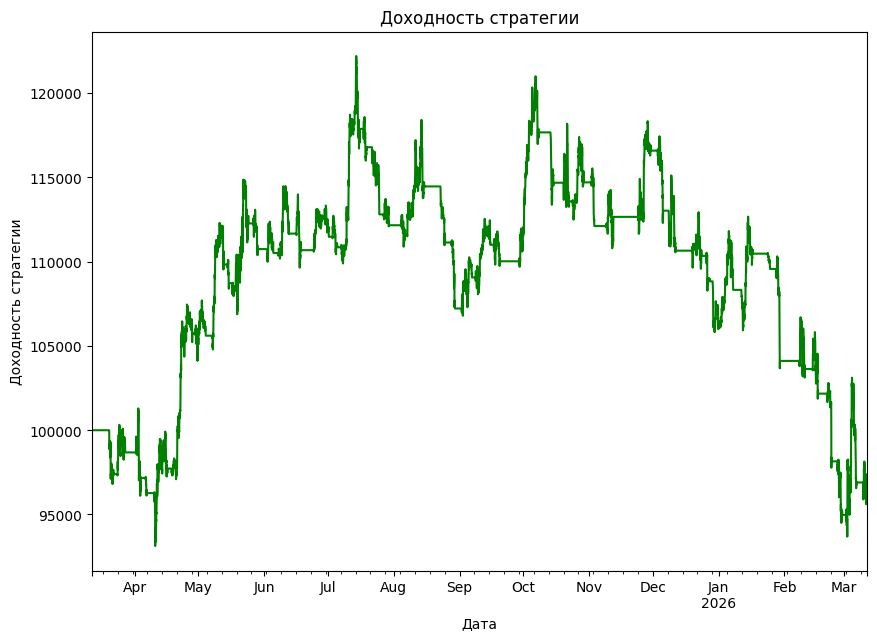

In [100]:
portfolio['equity'].plot(figsize=(10, 7), color='green')
plt.title('Доходность стратегии')
plt.xlabel('Дата')
plt.ylabel('Доходность стратегии')
plt.show

In [24]:
# Общее число торговых дней
days = len(equity) / 24
years = days / 365

start_capital = equity[0]
end_capital = equity[-1]

# Расчёт кумулятивной доходности
cumulative_return = end_capital / start_capital - 1

# Вычисление среднегодовой доходности (с учетом реинвестирования)
# из расчета 365 торговых дней в год
annualised_returns = (end_capital / start_capital) ** (1 / years) - 1

# Ежегодная волатильность
strategy_returns = portfolio['price'].pct_change()
annualised_volatility = np.std(strategy_returns)*(np.sqrt(365))*100

print(f"Кумулятивная доходность: {cumulative_return:.2%}")
print(f'Ежегодная доходность стратегии: {annualised_returns:.2%}')
print(f'Ежегодная волатильность: {annualised_volatility:.2f}%')

Кумулятивная доходность: 650.26%
Ежегодная доходность стратегии: 26.25%
Ежегодная волатильность: 14.89%


In [106]:
# Общее число торговых дней
days = len(equity)
# Вычисление совокупного среднегодового темпа роста
# из расчета 252 торговых дней в год
annualised_returns = (equity.iloc[-1]**(252/days)-1)*100

# Ежегодная волатильность
annualised_volatility = np.std(data.strategy_returns)*(252**0.5)*100

# Предполагаемая среднегодовая безрисковая ставка 1%
risk_free_rate = 0.01/252
sharpe_ratio = np.sqrt(252)*(np.mean(data.strategy_returns) -
(risk_free_rate))/np.std(data.strategy_returns)
downside_returns = np.where(data['strategy_returns'] < 0, data['strategy_returns'], 0)
expected_return = np.mean(data['strategy_returns']) - risk_free_rate
downside_risk = np.std(downside_returns) * np.sqrt(252)
sortino_ratio = expected_return / downside_risk

# Текущий максимум
running_max = np.maximum.accumulate(equity.dropna())

# Показатель не должен опускаться ниже 1
running_max[running_max < 1] = 1

# Вычисление максимальной просадки
drawdown = (equity)/running_max - 1
max_dd = drawdown.min()*100

print(f'Ежегодная доходность стратегии: {annualised_returns:.2f}%\n'
f'Ежегодная волатильность: {annualised_volatility:.2f}%\n'
f'Безрисковая ставка: {risk_free_rate:.8f}\n'
f'Коэффициент Шарпа: {sharpe_ratio:.2f}\n'
f'Максимальная просадка: {max_dd:.2f}%\n'
f'Коэффициент Сортино: {sortino_ratio:.8f}\n')

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [29]:
short_windows = np.arange(5, 50)
long_windows = np.arange(20, 200)


In [14]:
def sma(arr, window):
    out = np.empty_like(arr)
    out[:] = np.nan

    cumsum = np.cumsum(arr)
    cumsum[window:] = cumsum[window:] - cumsum[:-window]

    out[window-1:] = cumsum[window-1:] / window
    return out


In [15]:
def generate_signal(close, short_w, long_w):
    sma_s = sma(close, short_w)
    sma_l = sma(close, long_w)

    signal = np.zeros(len(close), dtype=np.int8)

    signal[sma_s > sma_l] = 1
    signal[sma_s < sma_l] = -1

    return signal


In [72]:
@njit
def signals(close_prices, short_window, long_window):

    # Рассчитываем SMA
    sma50 = np.convolve(close_prices, np.ones(short_window)/short_window, mode='valid')
    sma200 = np.convolve(close_prices, np.ones(long_window)/long_window, mode='valid')

    # Выравниваем длины массивов, добавляя NaN в начало
    sma50 = np.concatenate((np.full(short_window - 1, np.nan), sma50))
    sma200 = np.concatenate((np.full(long_window - 1, np.nan), sma200))

    # Сигналы для покупки
    buy_signal = np.where(
    (sma50 >= sma200) & (np.roll(sma50, 1) <= np.roll(sma200, 1)), 1, 0)

    # Сигналы для продажи
    sell_signal = np.where((sma50 <= sma200) & (np.roll(sma50, 1) >= np.roll(sma200, 1)), -1, 0)

    # Итоговый сигнал: 1 (купить), -1 (продать), 0 (ничего не делать)
    signal = buy_signal + sell_signal

    return signal

In [35]:
@njit
def run_backtest(price, signal,
                 initial_cash=100000.0,
                 buy_pct=0.1,
                 commission=0.001,
                 lot_size=1):

    cash = initial_cash
    shares = 0.0

    for i in range(1, len(price)):
        p = price[i]
        s = signal[i-1]

        if s == 1:
            target = cash * buy_pct
            qty = np.floor(target / p / lot_size) * lot_size

            cost = qty * p
            fee = cost * commission

            if cost + fee <= cash and qty > 0:
                cash -= (cost + fee)
                shares += qty

        elif s == -1:
            if shares > 0:
                proceeds = shares * p
                fee = proceeds * commission

                cash += proceeds - fee
                shares = 0.0

    return cash + shares * price[-1]


In [53]:
def grid_search(price, short_windows, long_windows):

    results = []

    for short in short_windows:
        for long in long_windows:

            if short >= long:
                continue

            signal = generate_signal(price, short, long)

            final_value = execute_strategy(price, signal)[0]

            results.append((short, long, final_value[-1]))

    return results


In [77]:
from numba import njit, prange

@njit#(parallel=True)
def grid_search_fast(price, short_windows, long_windows):

    n = len(short_windows) * len(long_windows)

    shorts_arr = np.empty(n, dtype=np.float64)
    longs_arr = np.empty(n, dtype=np.float64)
    equities_arr = np.empty(n, dtype=np.float64)

    idx = 0

    for i in prange(len(short_windows)):
        for j in range(len(long_windows)):

            short = short_windows[i]
            long = long_windows[j]

            if short >= long:
                continue

            signal = signals(price, short, long)
            equity, cash, shares = execute_strategy(price, signal)

            shorts_arr[idx] = short
            longs_arr[idx] = long
            equities_arr[idx] = equity[-1]

            idx += 1

    return shorts_arr[:idx], longs_arr[:idx], equities_arr[:idx]


In [78]:
shorts, longs, equity = grid_search_fast(price, short_windows, long_windows)

In [79]:

results_df = pd.DataFrame({
    'short': shorts,
    'long': longs,
    'equity': equity
})



best = results_df.sort_values('equity', ascending=False, na_position='last').head(10)

print(best)


      short   long        equity
1680   14.0   80.0  2.523181e+06
1681   14.0   81.0  2.454563e+06
6124   40.0   75.0  2.176099e+06
4667   31.0   85.0  2.148428e+06
6281   41.0   74.0  2.122063e+06
1682   14.0   82.0  2.115209e+06
1887   15.0  107.0  2.104014e+06
2288   17.0  148.0  2.102776e+06
1886   15.0  106.0  2.085815e+06
6126   40.0   77.0  2.074705e+06


In [109]:
@njit
def generate_signals(price_array, short_window, long_window):
    """
    Генерирует массив сигналов на основе скользящих средних.
    """
    signals = np.zeros(len(price_array), dtype=np.int32)

    # Считаем средние один раз для эффективности
    sma_short = np.empty(len(price_array))
    sma_long = np.empty(len(price_array))

    for i in range(len(price_array)):
        if i < short_window:
            sma_short[i] = np.nan
        else:
            sma_short[i] = np.mean(price_array[i-short_window:i])

        if i < long_window:
            sma_long[i] = np.nan
        else:
            sma_long[i] = np.mean(price_array[i-long_window:i])

    # Генерируем сигналы: 1 (купить), -1 (продать)
    for i in range(1, len(price_array)):
        if np.isnan(sma_short[i]) or np.isnan(sma_long[i]):
            signals[i] = 0
        elif sma_short[i] > sma_long[i] and sma_short[i-1] <= sma_long[i-1]:
            signals[i] = 1 # Золотой крест (вход в лонг)
        elif sma_short[i] < sma_long[i] and sma_short[i-1] >= sma_long[i-1]:
            signals[i] = -1 # Крест смерти (вход в шорт)
        else:
            signals[i] = signals[i-1]

    return signals

In [161]:
from numba import njit
import numpy as np

@njit
def calculate_equity(price_array, signal_array):
    """
    Принимает массив цен и массив сигналов (1 или -1).
    Возвращает итоговый капитал (эквити).
    """
    capital = 1000.0  # Начальный капитал
    position = 0.0    # Текущая позиция (в акциях)
    cash = capital    # Наличные

    # Проходим по ценам, начиная со второго дня
    for i in range(1, len(price_array)):
        # Если сигнал изменился, закрываем старую и открываем новую позицию
        if signal_array[i] != signal_array[i-1]:
            # Закрываем позицию
            cash += position * price_array[i]
            position = 0.0

            # Открываем новую, если сигнал не 0
            if signal_array[i] == 1:
                position = cash / price_array[i] # Покупка на все деньги
                cash = 0.0
            elif signal_array[i] == -1:
                position = - (cash / price_array[i]) # Продажа в шорт на все деньги
                cash = 0.0

    # Финальный расчёт стоимости портфеля
    equity = cash + position * price_array[-1]
    return equity

In [36]:
@njit
def grid_search_fast(price, short_windows, long_windows):
    n_combos = len(short_windows) * len(long_windows)

    shorts_arr = np.empty(n_combos, dtype=np.int64)
    longs_arr = np.empty(n_combos, dtype=np.int64)
    equities_arr = np.empty(n_combos, dtype=np.float64)
    cash_arr = np.empty(n_combos, dtype=np.float64)
    shares_arr = np.empty(n_combos, dtype=np.float64)

    idx = 0
    for short in short_windows:
        for long in long_windows:
            if short >= long:
                continue

            # --- ЧИСТЫЕ ВЫЧИСЛЕНИЯ NUMBA ---
            signals = generate_signals(price, short, long)
            equity = calculate_equity(price, signals)

            shorts_arr[idx] = short
            longs_arr[idx] = long
            equities_arr[idx] = equity[-1]
            # cash_arr[idx] = cash
            # shares_arr[idx] = shares

            idx += 1

    # Обрезаем пустые ячейки в конце массива
    return shorts_arr, longs_arr, equities_arr#, cash_arr, shares_arr

In [166]:
# Подготовка данных (вне функций Numba)
price_np = np.array(price) # price должен быть массивом чисел

# Окна - обязательно массивы NumPy с типом int64
shorts_list = np.arange(5, 50)
longs_list = np.arange(20, 200)

# Вызов оптимизированной функции
shorts_res, longs_res, equities_res = grid_search_fast(price_np, shorts_list, longs_list)

# Сборка DataFrame (Pandas работает только здесь)
results_df = pd.DataFrame({
    'short': shorts_res,
    'long': longs_res,
    'equity': equities_res
})

In [167]:
best = results_df.sort_values('equity', ascending=False).head(10)

print(best)

      short  long        equity
6436     42    72  18055.709538
6592     43    72  18055.709538
6279     41    72  18055.709538
7503     49    68  18055.709538
7052     46    70  18055.709538
6121     40    72  18055.709538
6746     44    71  18055.709538
7504     49    69  18055.709538
6591     43    71  18055.709538
7203     47    69  18055.709538


In [93]:
def fast_sma(arr, window):

    out = np.empty(len(arr))
    out[:] = np.nan

    csum = np.cumsum(arr)

    for i in range(window - 1, len(arr)):
        total = csum[i]

        if i >= window:
            total -= csum[i - window]

        out[i] = total / window

    return out

def vectorized_sma(arr, window):

    out = np.empty(len(arr))
    out[:] = np.nan

    # Вычисляем накопленную сумму
    csum = np.cumsum(arr)

    # Вычисляем сумму по окну с помощью сдвига
    csum[window:] = csum[window:] - csum[:-window]

    # Заполняем результат, начиная с window-1
    out[window - 1:] = csum[window - 1:] / window

    return out

def signals(close_prices, short_window=50, long_window=200):

    # Рассчитываем SMA
    # sma50 = np.convolve(close_prices, np.ones(short_window)/short_window, mode='valid')
    # sma200 = np.convolve(close_prices, np.ones(long_window)/long_window, mode='valid')

    sma50 = vectorized_sma(close_prices, short_window)
    sma200 = vectorized_sma(close_prices, long_window)

    # Выравниваем длины массивов, добавляя NaN в начало
    # sma50 = np.concatenate((np.full(short_window - 1, np.nan), sma50))
    # sma200 = np.concatenate((np.full(long_window - 1, np.nan), sma200))

    # Сигналы для покупки
    buy_signal = np.where((sma50 >= sma200) & (np.roll(sma50, 1) <= np.roll(sma200, 1)), 1, 0)

    # Сигналы для продажи
    sell_signal = np.where((sma50 <= sma200) & (np.roll(sma50, 1) >= np.roll(sma200, 1)), -1, 0)

    # Итоговый сигнал: 1 (купить), -1 (продать), 0 (ничего не делать)
    signal = buy_signal + sell_signal

    return signal

def execute_strategy(open_price, signal,
                     initial_cash=100000.0,
                     buy_pct=0.8,
                     commission=0.001,
                     lot_size=0.0001):

    n = len(open_price)

    cash = initial_cash
    shares = 0

    equity = np.zeros(n)
    cash_arr = np.zeros(n)
    shares_arr = np.zeros(n)

    equity[0] = initial_cash
    cash_arr[0] = cash
    shares_arr[0] = 0

    for i in range(1, n):
        p = open_price[i]
        prev_signal = signal[i-1]

        # --- BUY ---
        if prev_signal == 1:

            # расчет позиции на сделку
            target_value = cash * buy_pct

            # перевод в лоты
            shares_to_buy = np.floor(target_value / p / lot_size) * lot_size

            cost = shares_to_buy * p
            fee = cost * commission

            if cost + fee <= cash and shares_to_buy > 0:
                cash -= (cost + fee)
                shares += shares_to_buy

        # --- SELL ---
        elif prev_signal == -1:
            shares_to_sell = shares

            if shares_to_sell > 0:
                proceeds = shares_to_sell * p
                fee = proceeds * commission

                cash += (proceeds - fee)
                shares = 0

        cash_arr[i] = cash
        shares_arr[i] = shares
        equity[i] = cash + shares * p

    return equity, cash, shares

def optimize_sma_strategy(open_prices,
                          close_prices,
                          short_min=5,
                          short_max=50,
                          long_min=20,
                          long_max=200):

    best_equity = -1.0

    best_short = 0
    best_long = 0

    results_count = 0

    # примерный размер массива результатов
    max_results = (short_max - short_min) * (long_max - long_min)

    results = np.zeros((max_results, 3))

    for short_window in range(short_min, short_max):

        for long_window in range(long_min, long_max):

            # short должен быть меньше long
            if short_window >= long_window:
                continue

            # =========================
            # Генерация сигналов
            # =========================
            signal = signals(
                close_prices,
                short_window,
                long_window
            )

            # =========================
            # Бэктест
            # =========================
            equity_curve, final_cash, final_shares = execute_strategy(
                open_prices,
                signal
            )

            final_equity = equity_curve[-1]

            # сохраняем результат
            results[results_count, 0] = short_window
            results[results_count, 1] = long_window
            results[results_count, 2] = final_equity

            results_count += 1

            # =========================
            # Лучшая стратегия
            # =========================
            if final_equity > best_equity:

                best_equity = final_equity
                best_short = short_window
                best_long = long_window

    return (
        best_short,
        best_long,
        best_equity,
        results[:results_count]
    )

open_prices = data['open'].values.astype(np.float64)
close_prices = data['close'].values.astype(np.float64)

best_short, best_long, best_equity, results = optimize_sma_strategy(
    open_prices,
    close_prices
)

print("BEST SHORT:", best_short)
print("BEST LONG:", best_long)
print("BEST EQUITY:", best_equity)

BEST SHORT: 36
BEST LONG: 85
BEST EQUITY: 2332620.321482002
